In [2]:
pip install flask-cors

Note: you may need to restart the kernel to use updated packages.


In [86]:
import pandas as pd
import numpy as np

In [87]:
data = pd.read_csv("D:/PENS-EEPIS/GEMASTIK 2025/sensor_data_export_2025-09-30.csv")

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26837 entries, 0 to 26836
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                26837 non-null  int64  
 1   Tip Count         26355 non-null  float64
 2   Rainfall (mm)     26355 non-null  float64
 3   Water Level (cm)  26782 non-null  float64
 4   Timestamp         26837 non-null  object 
dtypes: float64(3), int64(1), object(1)
memory usage: 1.0+ MB


In [89]:
data.head()

,ID,Tip Count,Rainfall (mm),Water Level (cm),Timestamp
0,26837,NaN,NaN,65.7,2025-06-30 12:40:35
1,26836,0.0,0.0,65.6,2025-06-30 12:38:35
2,26835,0.0,0.0,65.6,2025-06-30 12:36:35
3,26834,0.0,0.0,65.6,2025-06-30 12:34:35
4,26833,0.0,0.0,65.6,2025-06-30 12:32:35


In [90]:
data.tail()

,ID,Tip Count,Rainfall (mm),Water Level (cm),Timestamp
26832,32,NaN,NaN,0.0,2025-03-09 01:49:38
26833,30,NaN,NaN,0.0,2025-03-09 01:49:08
26834,29,NaN,NaN,0.0,2025-03-09 01:48:38
26835,28,NaN,NaN,0.0,2025-03-09 01:48:08
26836,27,NaN,NaN,0.0,2025-03-09 01:47:38


# Preprocessing

In [91]:
data.isnull().sum()

ID                    0
Tip Count           482
Rainfall (mm)       482
Water Level (cm)     55
Timestamp             0
dtype: int64

In [92]:
data = data.dropna()

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26300 entries, 1 to 26817
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                26300 non-null  int64  
 1   Tip Count         26300 non-null  float64
 2   Rainfall (mm)     26300 non-null  float64
 3   Water Level (cm)  26300 non-null  float64
 4   Timestamp         26300 non-null  object 
dtypes: float64(3), int64(1), object(1)
memory usage: 1.2+ MB


In [94]:
data.to_csv("data_latih.csv", index=False)

In [95]:
# Menghapus baris dengan Water Level = 0
data = data[data['Water Level (cm)'] != 0]

# Verifikasi hasil
print("Jumlah data sebelum penghapusan:", len(data))
print("\nMengecek nilai unik pada tip_count:")
print(data['Water Level (cm)'].value_counts().sort_index())
print("\nInformasi dataset setelah penghapusan:")
data.info()

Jumlah data sebelum penghapusan: 26292

Mengecek nilai unik pada tip_count:
Water Level (cm)
39.5     1
40.2     1
40.3     2
40.7     2
40.8     1
        ..
307.2    2
307.6    1
307.8    1
308.0    2
308.5    1
Name: count, Length: 982, dtype: int64

Informasi dataset setelah penghapusan:
<class 'pandas.core.frame.DataFrame'>
Index: 26292 entries, 1 to 26678
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                26292 non-null  int64  
 1   Tip Count         26292 non-null  float64
 2   Rainfall (mm)     26292 non-null  float64
 3   Water Level (cm)  26292 non-null  float64
 4   Timestamp         26292 non-null  object 
dtypes: float64(3), int64(1), object(1)
memory usage: 1.2+ MB


In [96]:
# Menghapus baris dengan Tip_count = 0
data = data[data['Tip Count'] != 0]

# Verifikasi hasil
print("Jumlah data sebelum penghapusan:", len(data))
print("\nMengecek nilai unik pada tip_count:")
print(data['Tip Count'].value_counts().sort_index())
print("\nInformasi dataset setelah penghapusan:")
data.info()

Jumlah data sebelum penghapusan: 2565

Mengecek nilai unik pada tip_count:
Tip Count
1.0      1579
2.0       499
3.0       193
4.0        89
5.0        58
6.0        32
7.0        21
8.0        11
9.0        16
10.0        6
11.0        7
12.0        5
13.0        1
14.0        4
15.0        2
16.0        4
17.0        2
18.0        4
19.0        1
20.0        2
21.0        2
22.0        2
23.0        1
24.0        2
25.0        1
27.0        3
28.0        5
31.0        2
33.0        1
39.0        2
46.0        1
55.0        1
59.0        1
62.0        1
85.0        1
88.0        1
93.0        1
130.0       1
Name: count, dtype: int64

Informasi dataset setelah penghapusan:
<class 'pandas.core.frame.DataFrame'>
Index: 2565 entries, 11 to 26664
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                2565 non-null   int64  
 1   Tip Count         2565 non-null   float64
 2   Rainfall (mm)     256

In [97]:
data.head()

,ID,Tip Count,Rainfall (mm),Water Level (cm),Timestamp
11,26826,3.0,0.6,65.4,2025-06-30 12:18:28
42,26795,1.0,0.2,250.8,2025-05-04 02:44:18
141,26696,2.0,0.4,251.0,2025-05-03 23:26:13
168,26669,1.0,0.2,250.9,2025-05-03 22:32:12
200,26637,1.0,0.2,251.1,2025-05-03 21:28:10


In [98]:
data.to_csv("data_bersih.csv", index=False)

# Modelling Pakai metode terbaik

In [99]:
import pandas as pd
df = pd.read_csv("D:/PENS-EEPIS/GEMASTIK 2025/data_bersih.csv")

In [100]:
data

,ID,Tip Count,Rainfall (mm),Water Level (cm),Timestamp
11,26826,3.0,0.6,65.4,2025-06-30 12:18:28
42,26795,1.0,0.2,250.8,2025-05-04 02:44:18
141,26696,2.0,0.4,251.0,2025-05-03 23:26:13
168,26669,1.0,0.2,250.9,2025-05-03 22:32:12
200,26637,1.0,0.2,251.1,2025-05-03 21:28:10
...,...,...,...,...,...
26590,247,2.0,0.4,279.7,2025-03-10 07:09:10
26593,244,1.0,0.2,276.5,2025-03-10 06:52:09
26595,242,14.0,2.8,276.7,2025-03-10 06:46:41
26596,241,9.0,1.8,275.2,2025-03-10 06:44:41


In [101]:
data.describe()

,ID,Tip Count,Rainfall (mm),Water Level (cm)
count,2565.000000,2565.000000,2565.000000,2565.000000
mean,12428.305263,2.375049,0.474932,260.659805
std,8070.036022,5.402201,1.080453,40.876705
min,173.000000,1.000000,0.200000,41.000000
25%,5393.000000,1.000000,0.200000,253.900000
50%,11558.000000,1.000000,0.200000,265.800000
75%,19883.000000,2.000000,0.400000,280.900000
max,26826.000000,130.000000,26.000000,308.000000


In [102]:
# 1. Melihat data rainfall dengan format yang lebih rapi
print("=== Data Rainfall ===")
print(data["Rainfall (mm)"].to_frame())

=== Data Rainfall ===
       Rainfall (mm)
11               0.6
42               0.2
141              0.4
168              0.2
200              0.2
...              ...
26590            0.4
26593            0.2
26595            2.8
26596            1.8
26664            0.6

[2565 rows x 1 columns]


In [147]:
fuzzy_flood_classification("data_bersih.csv")

               Timestamp  Rainfall (mm)  Water Level (cm)  Delta_WL_per_min  \
0    2025-03-09 09:44:02            0.6             287.1         -0.009440   
1    2025-03-10 06:44:41            1.8             275.2          0.750000   
2    2025-03-10 06:46:41            2.8             276.7         -0.036585   
3    2025-03-10 06:52:09            0.2             276.5          0.188051   
4    2025-03-10 07:09:10            0.4             279.7          0.096064   
...                  ...            ...               ...               ...   
2560 2025-05-03 21:28:10            0.2             251.1         -0.003123   
2561 2025-05-03 22:32:12            0.2             250.9          0.001851   
2562 2025-05-03 23:26:13            0.4             251.0         -0.001010   
2563 2025-05-04 02:44:18            0.2             250.8         -0.002243   
2564 2025-06-30 12:18:28            0.6              65.4               NaN   

      BaseScore  EscalatedScore  Label  
0         

,ID,Tip Count,Rainfall (mm),Water Level (cm),Timestamp,Delta_WL_per_min,Rainfall_index,BaseScore,EscalatedScore,Label
0,173,3.0,0.6,287.1,2025-03-09 09:44:02,-0.009440,0,0,0,Aman
1,241,9.0,1.8,275.2,2025-03-10 06:44:41,0.750000,0,0,1,Siaga
2,242,14.0,2.8,276.7,2025-03-10 06:46:41,-0.036585,1,1,1,Siaga
3,244,1.0,0.2,276.5,2025-03-10 06:52:09,0.188051,0,0,0,Aman
4,247,2.0,0.4,279.7,2025-03-10 07:09:10,0.096064,0,0,0,Aman
...,...,...,...,...,...,...,...,...,...,...
2560,26637,1.0,0.2,251.1,2025-05-03 21:28:10,-0.003123,0,0,0,Aman
2561,26669,1.0,0.2,250.9,2025-05-03 22:32:12,0.001851,0,0,0,Aman
2562,26696,2.0,0.4,251.0,2025-05-03 23:26:13,-0.001010,0,0,0,Aman
2563,26795,1.0,0.2,250.8,2025-05-04 02:44:18,-0.002243,0,0,0,Aman


In [ ]:
hasil_klasifikasi = fuzzy_flood_classification("data_latih.csv")
# Menampilkan data dengan label Waspada
print("\n=== Data dengan Label WASPADA ===")
data_waspada = hasil_klasifikasi[hasil_klasifikasi['Label'] == "Waspada"]
print(data_waspada[["Timestamp", "Rainfall (mm)", "Water Level (cm)", "Delta_WL_per_min", "Label"]])

# Menampilkan jumlah data Waspada
print(f"\nJumlah data dengan label Waspada: {len(data_waspada)}")

                Timestamp  Rainfall (mm)  Water Level (cm)  Delta_WL_per_min  \
0     2025-03-09 07:05:01            0.0               0.0              0.00   
1     2025-03-09 07:51:16            0.0               0.0              0.00   
2     2025-03-09 07:53:16            0.0               0.0              0.00   
3     2025-03-09 07:55:16            0.0               0.0              0.00   
4     2025-03-09 07:59:16            0.0               0.0              0.00   
...                   ...            ...               ...               ...   
26294 2025-06-30 12:30:35            0.0              65.7             -0.05   
26295 2025-06-30 12:32:35            0.0              65.6              0.00   
26296 2025-06-30 12:34:35            0.0              65.6              0.00   
26297 2025-06-30 12:36:35            0.0              65.6              0.00   
26298 2025-06-30 12:38:35            0.0              65.6               NaN   

       BaseScore  EscalatedScore Label 

In [151]:
hasil_klasifikasi.to_excel("hasil_klasifikasi.xlsx", index=False)

Gambar berhasil disimpan: membership_functions.png dan .pdf


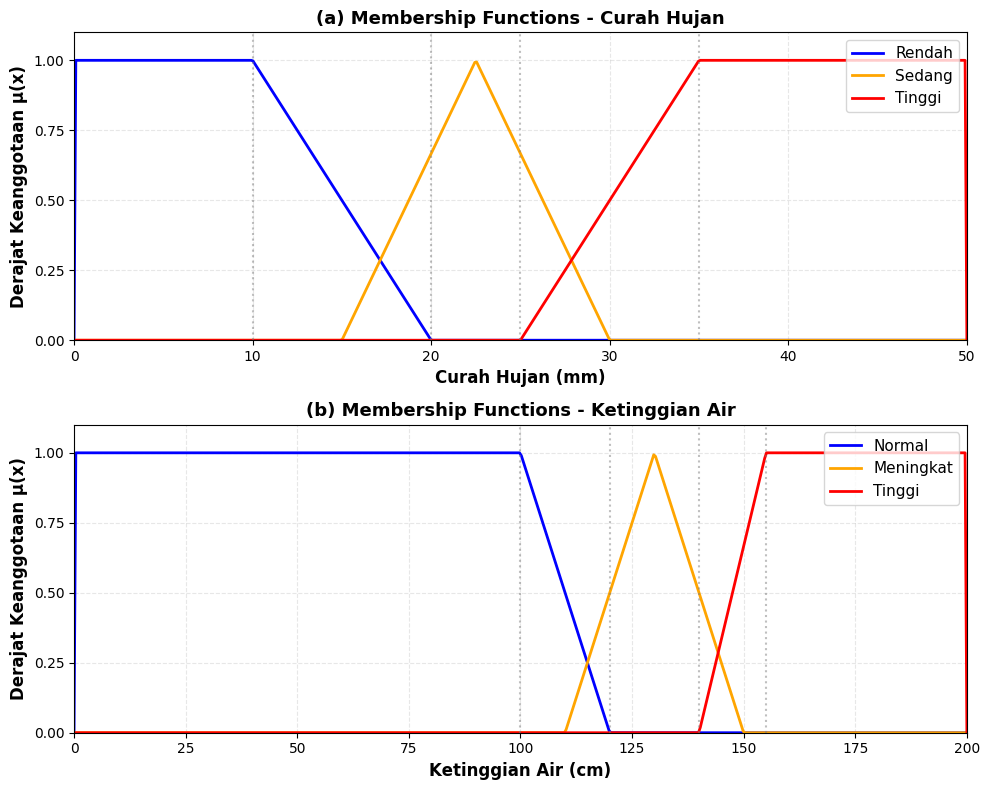

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Fungsi untuk membership functions
def trapezoid(x, a, b, c, d):
    """Fungsi trapesoid: flat antara b-c, naik a-b, turun c-d"""
    return np.maximum(0, np.minimum(1, np.minimum((x - a) / (b - a + 1e-10), 
                                                   (d - x) / (d - c + 1e-10))))

def triangular(x, a, b, c):
    """Fungsi segitiga: puncak di b, naik dari a, turun ke c"""
    return np.maximum(0, np.minimum((x - a) / (b - a + 1e-10), 
                                    (c - x) / (c - b + 1e-10)))

# Setup figure dengan 2 subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# ========== SUBPLOT 1: RAINFALL ==========
rainfall = np.linspace(0, 50, 500)

# Membership functions untuk rainfall
rendah_rain = trapezoid(rainfall, 0, 0, 10, 20)
sedang_rain = triangular(rainfall, 15, 22.5, 30)
tinggi_rain = trapezoid(rainfall, 25, 35, 50, 50)

ax1.plot(rainfall, rendah_rain, 'b-', linewidth=2, label='Rendah')
ax1.plot(rainfall, sedang_rain, 'orange', linewidth=2, label='Sedang')
ax1.plot(rainfall, tinggi_rain, 'r-', linewidth=2, label='Tinggi')

ax1.set_xlabel('Curah Hujan (mm)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Derajat Keanggotaan μ(x)', fontsize=12, fontweight='bold')
ax1.set_title('(a) Membership Functions - Curah Hujan', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper right', fontsize=11)
ax1.set_xlim([0, 50])
ax1.set_ylim([0, 1.1])
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

# Tambah marker di titik-titik penting
ax1.axvline(x=10, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=20, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=25, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=35, color='gray', linestyle=':', alpha=0.5)

# ========== SUBPLOT 2: WATER LEVEL ==========
water_level = np.linspace(0, 200, 500)

# Membership functions untuk water level
normal_water = trapezoid(water_level, 0, 0, 100, 120)
meningkat_water = triangular(water_level, 110, 130, 150)
tinggi_water = trapezoid(water_level, 140, 155, 200, 200)

ax2.plot(water_level, normal_water, 'b-', linewidth=2, label='Normal')
ax2.plot(water_level, meningkat_water, 'orange', linewidth=2, label='Meningkat')
ax2.plot(water_level, tinggi_water, 'r-', linewidth=2, label='Tinggi')

ax2.set_xlabel('Ketinggian Air (cm)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Derajat Keanggotaan μ(x)', fontsize=12, fontweight='bold')
ax2.set_title('(b) Membership Functions - Ketinggian Air', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', fontsize=11)
ax2.set_xlim([0, 200])
ax2.set_ylim([0, 1.1])
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

# Tambah marker di titik-titik penting
ax2.axvline(x=100, color='gray', linestyle=':', alpha=0.5)
ax2.axvline(x=120, color='gray', linestyle=':', alpha=0.5)
ax2.axvline(x=140, color='gray', linestyle=':', alpha=0.5)
ax2.axvline(x=155, color='gray', linestyle=':', alpha=0.5)

# Layout dan save
plt.tight_layout()
plt.savefig('membership_functions.png', dpi=300, bbox_inches='tight')
plt.savefig('membership_functions.pdf', bbox_inches='tight')  # untuk print quality
print("Gambar berhasil disimpan: membership_functions.png dan .pdf")
plt.show()

In [7]:
# -*- coding: utf-8 -*-
# Time-series visualization using the same fuzzy logic as your app.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ===================== Load & normalize =====================
df = pd.read_csv("data_latih.csv", usecols=["Timestamp", "Rainfall (mm)", "Water Level (cm)"])
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

In [8]:
# ===================== FUZZY SETS =====================
def fuzzify_rainfall_rendah(x):
    if x <= 10: return 1.0
    elif x >= 20: return 0.0
    else: return (20.0 - x) / 10.0

def fuzzify_rainfall_sedang(x):
    if x <= 15 or x >= 30: return 0.0
    elif x < 22.5: return (x - 15.0) / 7.5
    else: return (30.0 - x) / 7.5

def fuzzify_rainfall_tinggi(x):
    if x <= 25: return 0.0
    elif x >= 35: return 1.0
    else: return (x - 25.0) / 10.0

def fuzzify_water_normal(x):
    if x <= 100: return 1.0
    elif x >= 120: return 0.0
    else: return (120.0 - x) / 20.0

def fuzzify_water_meningkat(x):
    if x <= 110 or x >= 150: return 0.0
    elif x < 130: return (x - 110.0) / 20.0
    else: return (150.0 - x) / 20.0

def fuzzify_water_tinggi(x):
    if x <= 140: return 0.0
    elif x >= 155: return 1.0
    else: return (x - 140.0) / 15.0

def fuzzy_inference(rainfall, water_level):
    ch_r = fuzzify_rainfall_rendah(rainfall)
    ch_s = fuzzify_rainfall_sedang(rainfall)
    ch_t = fuzzify_rainfall_tinggi(rainfall)
    kt_n = fuzzify_water_normal(water_level)
    kt_m = fuzzify_water_meningkat(water_level)
    kt_t = fuzzify_water_tinggi(water_level)

    rules = [
        (min(ch_r, kt_n), 10),
        (min(ch_r, kt_m), 35),
        (min(ch_r, kt_t), 60),
        (min(ch_s, kt_n), 40),
        (min(ch_s, kt_m), 65),
        (min(ch_s, kt_t), 85),
        (min(ch_t, kt_n), 60),
        (min(ch_t, kt_m), 85),
        (min(ch_t, kt_t), 95),
    ]
    num = sum(a * s for a, s in rules)
    den = sum(a for a, _ in rules)
    return 10.0 if den == 0 else num / den


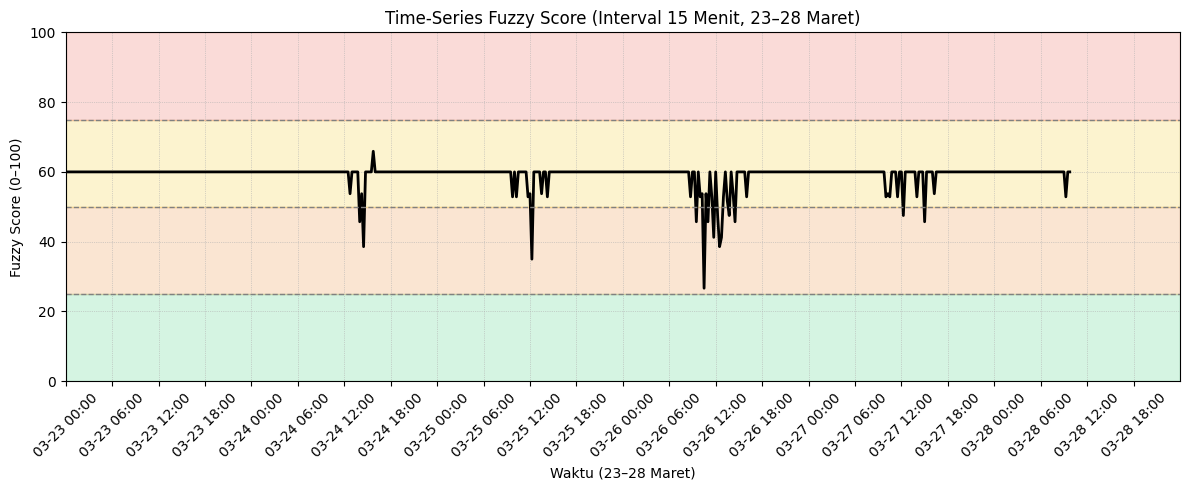

In [9]:
# ===================== HITUNG FUZZY SCORE =====================
df["fuzzy_score"] = [fuzzy_inference(r, wl) for r, wl in zip(df["Rainfall (mm)"], df["Water Level (cm)"])]

# ===================== FILTER & RESAMPLE =====================
start_time = pd.Timestamp("2025-03-23 00:00:00")
end_time = pd.Timestamp("2025-03-28 23:59:59")

df_filtered = df[(df["Timestamp"] >= start_time) & (df["Timestamp"] <= end_time)]
df_resampled = (
    df_filtered.set_index("Timestamp")
    .resample("15T")       # interval 15 menit
    .mean()
    .reset_index()
)

# ===================== PLOT =====================
fig, ax = plt.subplots(figsize=(12, 5))

# Zona warna (background)
ax.axhspan(0, 25, alpha=0.2, color="#2ecc71", label="Aman")    # hijau
ax.axhspan(25, 50, alpha=0.2, color="#e67e22", label="Waspada")# oranye
ax.axhspan(50, 75, alpha=0.2, color="#f1c40f", label="Siaga")  # kuning
ax.axhspan(75, 100, alpha=0.2, color="#e74c3c", label="Bahaya")# merah

# Garis fuzzy score
ax.plot(df_resampled["Timestamp"], df_resampled["fuzzy_score"],
        color="black", linewidth=2, label="Fuzzy Score (15 menit)")

# Garis ambang
for th in (25, 50, 75):
    ax.axhline(th, linestyle="--", color="gray", linewidth=1)

# Format sumbu waktu setiap 15 menit
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # tiap 6 jam biar tidak padat
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)

# Label dan tampilan
ax.set_xlim(start_time, end_time)
ax.set_ylim(0, 100)
ax.set_xlabel("Waktu (23–28 Maret)")
ax.set_ylabel("Fuzzy Score (0–100)")
ax.set_title("Time-Series Fuzzy Score (Interval 15 Menit, 23–28 Maret)")
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()
